In [45]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [46]:
df = pd.read_csv('titanic_50000.csv')

In [47]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,1,Passenger_1,male,28.505531,4,1,TCKT84588,21.803954,NaN,S
1,2,1,1,Passenger_2,female,16.290422,0,3,TCKT87215,25.140471,NaN,S
2,3,0,3,Passenger_3,male,54.239256,3,4,TCKT56430,62.139033,NaN,S
3,4,0,3,Passenger_4,female,25.934960,1,2,TCKT97536,70.722917,C187,Q
4,5,0,3,Passenger_5,female,44.024119,2,3,TCKT56341,11.959749,NaN,S


In [48]:
df.shape

(50000, 12)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  50000 non-null  int64  
 1   Survived     50000 non-null  int64  
 2   Pclass       50000 non-null  int64  
 3   Name         50000 non-null  object 
 4   Sex          50000 non-null  object 
 5   Age          50000 non-null  float64
 6   SibSp        50000 non-null  int64  
 7   Parch        50000 non-null  int64  
 8   Ticket       50000 non-null  object 
 9   Fare         50000 non-null  float64
 10  Cabin        15004 non-null  object 
 11  Embarked     50000 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 4.6+ MB


In [50]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,0.499080,2.299300,30.094317,2.485500,2.493500,48.969638
std,14433.901067,0.500004,0.780161,13.788365,1.708581,1.704704,35.807589
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.003933
25%,12500.750000,0.000000,2.000000,20.589989,1.000000,1.000000,20.043044
50%,25000.500000,0.000000,2.000000,30.004980,2.000000,2.000000,42.437014
75%,37500.250000,1.000000,3.000000,39.458093,4.000000,4.000000,70.797499
max,50000.000000,1.000000,3.000000,80.000000,5.000000,5.000000,265.836314


In [51]:
df.isnull().sum()

PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age                0
SibSp              0
Parch              0
Ticket             0
Fare               0
Cabin          34996
Embarked           0
dtype: int64

In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,1,Passenger_1,male,28.505531,4,1,TCKT84588,21.803954,NaN,S
1,2,1,1,Passenger_2,female,16.290422,0,3,TCKT87215,25.140471,NaN,S
2,3,0,3,Passenger_3,male,54.239256,3,4,TCKT56430,62.139033,NaN,S
3,4,0,3,Passenger_4,female,25.934960,1,2,TCKT97536,70.722917,C187,Q
4,5,0,3,Passenger_5,female,44.024119,2,3,TCKT56341,11.959749,NaN,S


In [54]:
data_set = df[['Pclass', 'Age', 'Cabin', 'Survived']]
data_set.head()

,Pclass,Age,Cabin,Survived
0,1,28.505531,NaN,0
1,1,16.290422,NaN,1
2,3,54.239256,NaN,0
3,3,25.934960,C187,0
4,3,44.024119,NaN,0


In [55]:
data_set.describe()

,Pclass,Age,Survived
count,50000.000000,50000.000000,50000.000000
mean,2.299300,30.094317,0.499080
std,0.780161,13.788365,0.500004
min,1.000000,0.000000,0.000000
25%,2.000000,20.589989,0.000000
50%,2.000000,30.004980,0.000000
75%,3.000000,39.458093,1.000000
max,3.000000,80.000000,1.000000


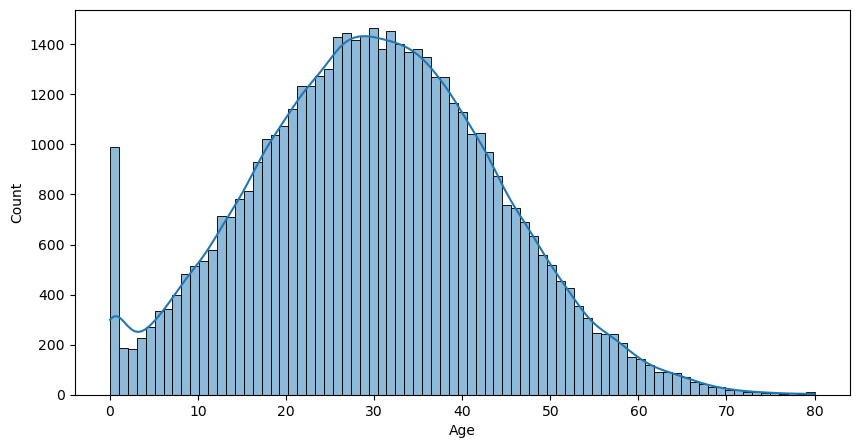

In [56]:
plt.figure(figsize=(10,5))
sns.histplot(data_set['Age'], kde=True)
plt.show()

<Axes: ylabel='Age'>

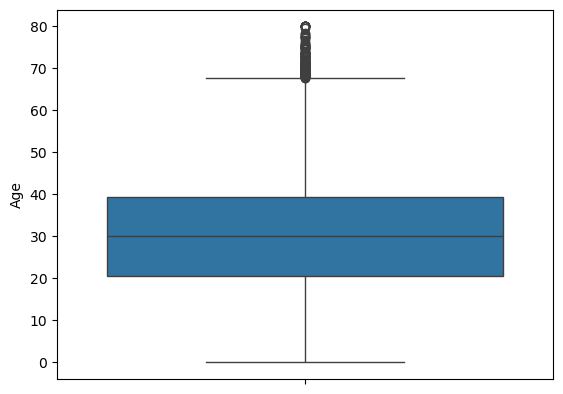

In [57]:
sns.boxplot(data_set['Age'])

In [58]:
# Z-score method 
upper_limit = data_set['Age'].mean() + 3*data_set['Age'].std()
lower_limit = data_set['Age'].mean() - 3*data_set['Age'].std()

print('upper_limit', upper_limit)
print('lower_limit', lower_limit)

upper_limit 71.45941332246035
lower_limit -11.270779298763475


In [59]:
data_set.loc[(data_set['Age'] > upper_limit) | (data_set['Age'] < lower_limit)]

,Pclass,Age,Cabin,Survived
556,2,72.077966,NaN,1
686,3,73.121616,NaN,1
778,3,77.591351,NaN,1
913,3,75.636736,NaN,1
1623,1,72.760810,NaN,1
...,...,...,...,...
43437,3,80.000000,NaN,0
44842,3,71.970264,NaN,1
47562,3,74.133844,NaN,1
48169,2,80.000000,NaN,0


old_data 50000
new_data 49936


<Axes: ylabel='Age'>

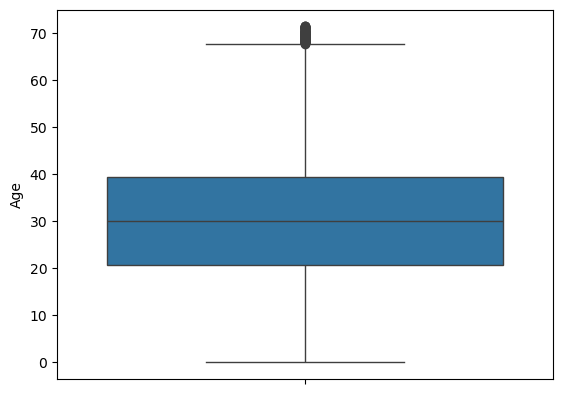

In [60]:
#Triming...
new_df = data_set.loc[(data_set['Age'] < upper_limit) & (data_set['Age'] > lower_limit)]
print('old_data', len(data_set))
print('new_data', len(new_df))
sns.boxplot(new_df['Age'])

In [61]:
#capping...
new_df = data_set.copy()
new_df.loc[(new_df['Age'] > upper_limit), 'Age'] = upper_limit
new_df.loc[(new_df['Age'] < lower_limit), 'Age'] = lower_limit

<Axes: ylabel='Age'>

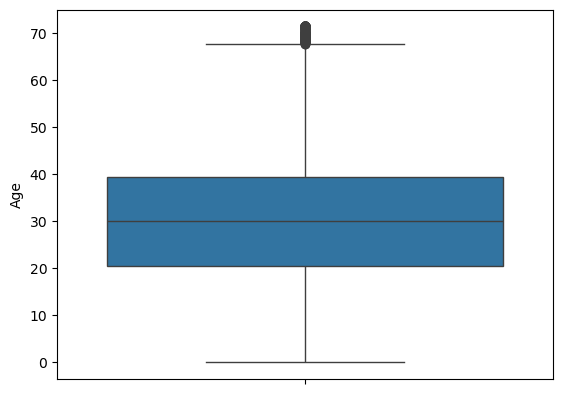

In [62]:
sns.boxplot(new_df['Age'])

<Axes: xlabel='Age', ylabel='Count'>

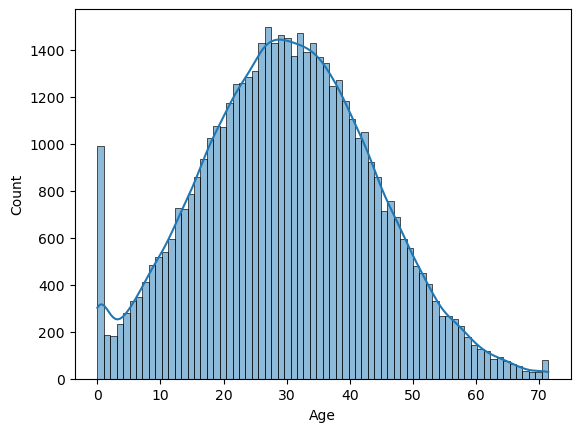

In [63]:
sns.histplot(new_df['Age'], kde=True)

In [65]:
new_df.head()

,Pclass,Age,Cabin,Survived
0,1,28.505531,NaN,0
1,1,16.290422,NaN,1
2,3,54.239256,NaN,0
3,3,25.934960,C187,0
4,3,44.024119,NaN,0


In [67]:
new_df.shape

(50000, 4)

In [68]:
from sklearn.model_selection import train_test_split 

In [72]:
x = new_df.drop('Survived', axis=1)
y = new_df['Survived']

x_train, x_test, y_train, y_test = train_test_split(
    x, 
    y, 
    test_size=0.3, 
    random_state=1
)

x_train.size, y_train.size

(105000, 35000)

In [73]:
x_train.head()

,Pclass,Age,Cabin
8950,3,6.666284,NaN
38421,2,50.665509,C30
19363,1,15.629627,NaN
30157,3,11.262938,NaN
14294,1,34.530708,NaN
